In [1]:
%matplotlib inline

import os, warnings

import numpy as np
import scipy as sp
import pandas as pd
from tqdm import tqdm
import bct

import torch
from src.utils import get_my_colors
from src.plotting import my_reg_plot

# import plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({"font.size": 8})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='Arial')
sns.set_style("white")

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
# directories
tracto_string = 'probabilistic_sift_radius2_count'
datadir = '/home/lindenmp/research_projects/neuro_rnn/data/{0}'.format(tracto_string)
modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/pytorch/model'
outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs'

In [3]:
# Device configuration
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')

In [4]:
# load data
file_str = 'task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-100-25000_wmask-True-14-27_reg-l2-0.002-sa_axis'
log_args = np.load(os.path.join(modeldir, file_str + '.npy'), allow_pickle=True).item()

test_accuracy = log_args['test_accuracy']
n_logged_epochs = log_args['test_accuracy'].shape[-1]
n_runs, n_epochs = log_args['training_loss'].shape
hidden_size = log_args['hidden_activity'].shape[-1]

checkpoint = torch.load(os.path.join(modeldir, file_str + '.pt'), map_location=device)
hidden_weights = np.zeros((n_runs, n_logged_epochs, hidden_size, hidden_size))
for i, run in enumerate(checkpoint.keys()):
    for j, epoch in enumerate(checkpoint[run].keys()):
        hidden_weights[i, j] = checkpoint[run][epoch]['rnn.weight_hh_l0']
del checkpoint

x_start = 1
test_accuracy = test_accuracy[:, x_start:101]
hidden_weights = hidden_weights[:, x_start:101]
n_logged_epochs = test_accuracy.shape[-1]
n_epochs = (test_accuracy.shape[1] - 1) * 100
x_step = int(n_epochs / (n_logged_epochs-1))

print(test_accuracy.shape)
print(hidden_weights.shape)
print(n_logged_epochs, n_epochs)

(100, 100)
(100, 100, 100, 100)
100 9900


### Connectome weights

In [5]:
dataset = 'pnc'
# dataset = 'hbn_1'
# dataset = 'hbn_3'
# dataset = 'all'

which_feature = 'edge'
# which_feature = 'strength'

In [6]:
n_parcels = int(hidden_size * 2)

A_pnc = np.load(os.path.join(datadir, '{0}_schaefer{1}-7_A.npy').format('pnc', n_parcels))
A_pnc = np.load(os.path.join(datadir, '{0}_schaefer{1}-7_A.npy').format('pnc', n_parcels))
A_pnc = A_pnc[:hidden_size, :hidden_size, :]
Am_pnc = np.load(os.path.join(datadir, '{0}_schaefer{1}-7_Am.npy').format('pnc', n_parcels))
Am_pnc = Am_pnc[:hidden_size, :hidden_size]
df_pnc = pd.read_csv(os.path.join(datadir, '{0}_schaefer{1}-7_df.csv').format('pnc', n_parcels), index_col=0)

A_hbn = np.load(os.path.join(datadir, '{0}_schaefer{1}-7_A.npy').format('hbn', n_parcels))
A_hbn = A_hbn[:hidden_size, :hidden_size, :]
Am_hbn = np.load(os.path.join(datadir, '{0}_schaefer{1}-7_Am.npy').format('hbn', n_parcels))
Am_hbn = Am_hbn[:hidden_size, :hidden_size]
df_hbn = pd.read_csv(os.path.join(datadir, '{0}_schaefer{1}-7_df.csv').format('hbn', n_parcels), index_col=0)

In [7]:
if dataset == 'pnc':
    Am_human = Am_pnc
    A_human = A_pnc
    df_human = df_pnc
elif dataset == 'hbn_1':
    Am_human = Am_hbn
    A_human = A_hbn
    df_human = df_hbn
    df_human = df_human[df_hbn['study_site'] == 'HBN-1']
    A_human = A_human[:, :, df_hbn['study_site'] == 'HBN-1']
elif dataset == 'hbn_3':
    Am_human = Am_hbn
    A_human = A_hbn
    df_human = df_hbn
    df_human = df_human[df_hbn['study_site'] == 'HBN-3']
    A_human = A_human[:, :, df_hbn['study_site'] == 'HBN-3']
else:
    Am_human = (Am_pnc + Am_hbn) / 2
    cols = ['age', 'sex', 'study', 'study_site']
    df_human = pd.concat((df_pnc[cols], df_hbn[cols]), axis=0)
    A_human = np.concatenate((A_pnc, A_hbn), axis=2)
    # df_human = pd.concat((df_pnc[cols], df_hbn[df_hbn['study_site'] == 'HBN-3'][cols]), axis=0)
    # A_human = np.concatenate((A_pnc, A_hbn[:, :, df_hbn['study_site'] == 'HBN-3']), axis=2)

print(A_human.shape, df_human.shape)
print(df_human['age'].describe())
n_subjects = A_human.shape[-1]

(100, 100, 869) (869, 23)
count    869.000000
mean      15.302839
std        3.406230
min        8.166667
25%       12.750000
50%       15.583333
75%       18.000000
max       23.000000
Name: age, dtype: float64


<Axes: >

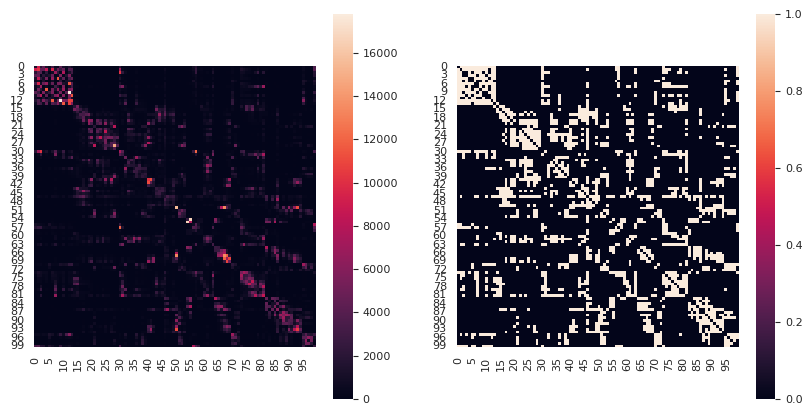

In [8]:
thresh = np.quantile(Am_human, q=0.8)
mask = Am_human > thresh
Am_human_thresh = Am_human.copy()
Am_human_thresh[mask] = 1
Am_human_thresh[~mask] = 0
np.fill_diagonal(Am_human_thresh, 0)

f, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.heatmap(Am_human, ax=ax[0], square=True)
sns.heatmap(Am_human_thresh, ax=ax[1], square=True)

In [9]:
subj_filter = np.zeros(n_subjects).astype(bool)
for i in np.arange(n_subjects):
    if np.all(A_human[:, :, i] == 0):
        subj_filter[i] = True

    if np.any(np.isnan(A_human[:, :, i])):
        subj_filter[i] = True

    if np.any(np.isinf(A_human[:, :, i])):
        subj_filter[i] = True

    if np.std(A_human[:, :, i]) == 0:
        subj_filter[i] = True

    if bct.density_und(A_human[:,:,i])[0] < .001:
        subj_filter[i] = True

In [10]:
if np.any(subj_filter):
    df_human = df_human[~subj_filter]
    A_human = A_human[:, :, ~subj_filter]
    print(A_human.shape, df_human.shape)
    print(df_human['age'].describe())
    n_subjects = A_human.shape[-1]

### RNN weights

# Stats

In [11]:
from numba import njit

@njit
def get_mean(x):
    n = len(x)
    m = np.empty(n)
    for i in range(n):
        m[i] = x[i].mean()
    return m

@njit
def get_std(x):
    n = len(x)
    s = np.empty(n)
    for i in range(n):
        s[i] = x[i].std()
    return s

@njit
def get_corr_fast(x, y):
    ''' Correlation '''
    n, k = x.shape
    m, k = y.shape

    mu_a = get_mean(x)
    mu_b = get_mean(y)
    sig_a = get_std(x)
    sig_b = get_std(y)

    corr_coef = np.empty((n, m))

    for i in range(n):
        for j in range(m):
            corr_coef[i, j] = (x[i] - mu_a[i]) @ (y[j] - mu_b[j]) / k / sig_a[i] / sig_b[j]

    return corr_coef

In [12]:
if which_feature == 'edge':
    # weight_mask = Am_human > 0
    weight_mask = Am_human_thresh > 0
    # weight_mask = Am_human[masks['bystanders_bystanders']] > 0
    n_features = np.sum(weight_mask)
    print(n_features)
    rnn_features = np.zeros((n_runs, n_logged_epochs, n_features))
    for run in tqdm(np.arange(n_runs)):
        for epoch in np.arange(n_logged_epochs):
            A = np.abs(hidden_weights[run, epoch]).copy()
            A = (A + A.T) / 2
            # A = A[masks['bystanders_bystanders']]
            A = A[weight_mask]
            rnn_features[run, epoch, :] = A
            rnn_features[run, epoch, :] = sp.stats.rankdata(rnn_features[run, epoch, :])

    human_features = np.zeros((n_subjects, n_features))
    for subj in np.arange(n_subjects):
        A = A_human[:, :, subj].copy()
        # A = A[masks['bystanders_bystanders']]
        A = A[weight_mask]
        human_features[subj, :] = A
        human_features[subj, :] = sp.stats.rankdata(human_features[subj, :])

elif which_feature == 'strength':
    n_features = hidden_size
    # n_features = np.sum(masks['bystanders'])
    rnn_features = np.zeros((n_runs, n_logged_epochs, n_features))
    for run in tqdm(np.arange(n_runs)):
        for epoch in np.arange(n_logged_epochs):
            A = np.abs(hidden_weights[run, epoch]).copy()
            np.fill_diagonal(A, 0)
            A = (A + A.T) / 2
            # retain only bystanders
            # A = A[masks['bystanders_bystanders']]
            # A = A.reshape(np.sum(masks['bystanders']), np.sum(masks['bystanders']))

            rnn_features[run, epoch, :] = bct.strengths_und(A)
            rnn_features[run, epoch, :] = sp.stats.rankdata(rnn_features[run, epoch, :])

    human_features = np.zeros((n_subjects, n_features))
    for subj in np.arange(n_subjects):
        A = A_human[:, :, subj].copy()
        np.fill_diagonal(A, 0)
        # retain only bystanders
        # A = A[masks['bystanders_bystanders']]
        # A = A.reshape(np.sum(masks['bystanders']), np.sum(masks['bystanders']))

        human_features[subj, :] = bct.strengths_und(A)
        human_features[subj, :] = sp.stats.rankdata(human_features[subj, :])

feature_corr = np.zeros((n_runs, n_logged_epochs, n_subjects))
for run in tqdm(np.arange(n_runs)):
    feature_corr[run] = get_corr_fast(rnn_features[run, :, :], human_features)
feature_corr_mean = np.mean(feature_corr, axis=0)

print(rnn_features.shape, human_features.shape)
print(feature_corr.shape, feature_corr_mean.shape)

1906


100%|██████████| 100/100 [00:06<00:00, 16.06it/s]

(100, 100, 1906) (869, 1906)
(100, 100, 869) (100, 869)


In [13]:
age_corr = np.zeros((n_runs, n_logged_epochs))
for run in tqdm(np.arange(n_runs)):
    for epoch in np.arange(n_logged_epochs):
        age_corr[run, epoch] = sp.stats.spearmanr(df_human['age'], feature_corr[run, epoch])[0]

age_corr_mean = np.zeros(n_logged_epochs)
for epoch in tqdm(np.arange(n_logged_epochs)):
    age_corr_mean[epoch] = sp.stats.spearmanr(df_human['age'], feature_corr_mean[epoch])[0]

print(age_corr.shape, age_corr_mean.shape)

100%|██████████| 100/100 [00:00<00:00, 4628.10it/s]

(100, 100) (100,)


[ 3 32 61 90]


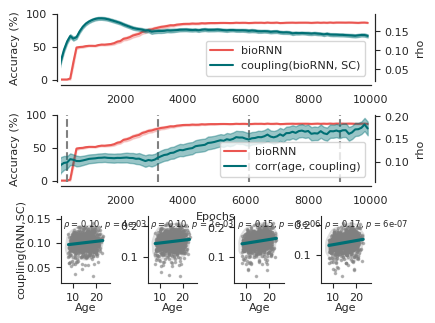

In [14]:
fig_width = 4
fig_height = 3.5
f = plt.figure(layout=None, figsize=(fig_width, fig_height))
gs = f.add_gridspec(nrows=3, ncols=4, hspace=0.5, wspace=0.75)
ax1 = f.add_subplot(gs[0, :])
ax1_twin = ax1.twinx()
ax2 = f.add_subplot(gs[1, :])
ax2_twin = ax2.twinx()

ax3_0 = f.add_subplot(gs[2, 0])
ax3_1 = f.add_subplot(gs[2, 1])
ax3_2 = f.add_subplot(gs[2, 2])
ax3_3 = f.add_subplot(gs[2, 3])
ax3_list = [ax3_0, ax3_1, ax3_2, ax3_3]

x = np.arange(0, n_epochs + x_step, x_step)
indices = np.linspace(3, n_logged_epochs-10, 4).astype(int)
print(indices)
n_indices = len(indices)

# row 1, 2 : add accuracy to both
my_colors = get_my_colors()
accuracy_mean = test_accuracy.mean(axis=0)*100
accuracy_std = test_accuracy.std(axis=0)*100
ci = 1.96 * (accuracy_std / np.sqrt(n_runs))
accuracy_ci_lower = accuracy_mean - ci
accuracy_ci_upper = accuracy_mean + ci
for this_ax in [ax1, ax2]:
    this_ax.plot(x, accuracy_mean, color=my_colors['raspberry_blush'], label='bioRNN')
    this_ax.fill_between(x, accuracy_ci_lower, accuracy_ci_upper, color=my_colors['raspberry_blush'], alpha=0.25)
    this_ax.set_ylim([-2.5, 100])
    this_ax.set_xlim([x_start*100, (n_logged_epochs+x_start-1)*100])
    this_ax.set_ylabel('Accuracy (%)')
ax2.set_xlabel('Epochs')

# row 1
coupling_mean = feature_corr.mean(axis=-1).mean(axis=0)
coupling_std = feature_corr.mean(axis=-1).std(axis=0)
ci = 1.96 * (coupling_std / np.sqrt(n_runs))
ax1_twin.plot(x, coupling_mean, color=my_colors['north_sea_green'], label='coupling(bioRNN, SC)')
ax1_twin.fill_between(x, coupling_mean - ci, coupling_mean + ci, color=my_colors['north_sea_green'], alpha=0.4)
ax1_twin.set_ylabel('rho')
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1_twin.legend(lines + lines2, labels + labels2, loc='lower right')

# row 2
age_corr_std = age_corr.std(axis=0)
ci = 1.96 * (age_corr_std / np.sqrt(n_runs))
ax2_twin.plot(x, age_corr_mean, color=my_colors['north_sea_green'], label='corr(age, coupling)')
ax2_twin.fill_between(x, age_corr_mean - ci, age_corr_mean + ci, color=my_colors['north_sea_green'], alpha=0.4)
ax2_twin.set_ylabel('rho')
lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2_twin.legend(lines + lines2, labels + labels2, loc='lower right')

for this_ax in [ax1, ax1_twin, ax2, ax2_twin]:
    sns.despine(offset=3, trim=False, left=False, right=False, top=True, bottom=False, ax=this_ax)

# row 3
for i, epoch in enumerate(indices):
    if i == 0:
        ylabel = 'coupling(RNN,SC)'
    else:
        ylabel = ''
    my_reg_plot(x=df_human['age'], y=feature_corr_mean[epoch-x_start],
                xlabel='Age', ylabel=ylabel, ax=ax3_list[i], annotate='spearman', fontsize=6)
    sns.despine(offset=0, trim=False, left=False, right=True, top=True, bottom=False, ax=ax3_list[i])

    # add vertical lines to other plots
    ax2.axvline(epoch*100, color='gray', linestyle='--')

file_str2 = '{0}_corr(RNN_sc,{1}_sc).svg'.format(file_str, dataset)
plt.show()
f.savefig(os.path.join(outdir, file_str2), dpi=300, bbox_inches='tight', pad_inches=0.01)